In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from timeit import default_timer as timer



print(torch.cuda.is_available())
print(torch.distributed.is_available())
print(torch.distributed.is_nccl_available())


True
True
True


In [2]:
import requests
from pathlib import Path
import zipfile 
import subprocess
file_path = Path("mini_food")

image_path = file_path /"pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists")
    
else:
    command = list("chmod +rwx mini_food".split())
    print(command)
    subprocess.run(command,shell=True)
    image_path.mkdir(parents=True,exist_ok=True)
    
    with open(file_path / "pizza_steak_sushi.zip","wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)
        print("successfully downloaded dataset")
        
    
    with zipfile.ZipFile(file_path / "pizza_steak_sushi.zip","r") as z:
        print("unzipping....")
        z.extractall(image_path)

print("done unzipping")

['chmod', '+rwx', 'mini_food']


chmod: missing operand
Try 'chmod --help' for more information.


successfully downloaded dataset
unzipping....
done unzipping


In [ ]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'mini_food/pizza_steak_sushi'.
There are 3 directories and 0 images in 'mini_food/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'mini_food/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'mini_food/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'mini_food/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in 'mini_food/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'mini_food/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'mini_food/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'mini_food/pizza_steak_sushi/train/pizza'.


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('mini_food/pizza_steak_sushi/train'),
 PosixPath('mini_food/pizza_steak_sushi/test'))

Random image path: mini_food/pizza_steak_sushi/train/sushi/2574453.jpg
Image class: sushi
Image height: 512
Image width: 512


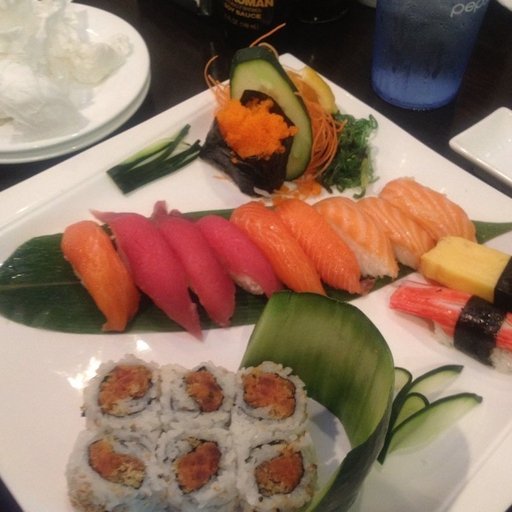

In [7]:
import random
from PIL import Image

# random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))


random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

Text(0.5, 1.0, 'sushi Image')

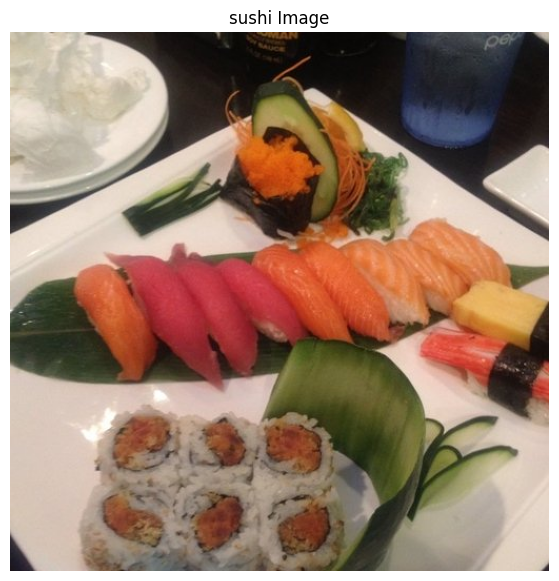

In [8]:
import numpy as np
import matplotlib.pyplot as plt


image_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_array)
plt.axis(False)
plt.title(f"{image_class} Image")


In [10]:
data_transform = transforms.Compose(
    [
        transforms.Resize(size=(64,64)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor()
    ]
)


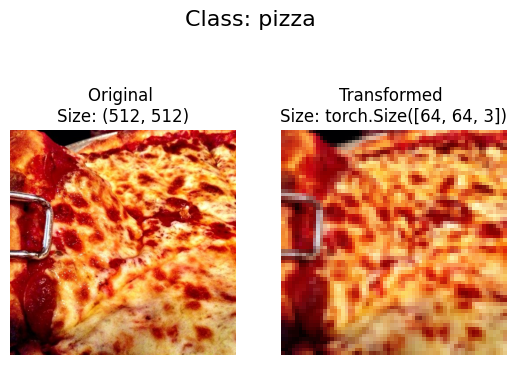

In [12]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=1)

In [13]:
a = torch.rand([4,2,4])
print(a.shape)
a = a.permute(0,2,1)
a.shape

torch.Size([4, 2, 4])


torch.Size([4, 4, 2])

In [14]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform = data_transform
)

train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: mini_food/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: mini_food/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [15]:
class_names,class_dict = train_data.classes,train_data.class_to_idx
class_names,class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [17]:
import os
os.cpu_count()

24

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = os.cpu_count() - 2
LOCAL_RANK = int(os.environ.get('LOCAL_RANK', 0))
WORLD_SIZE = int(os.environ.get('WORLD_SIZE', 1))
WORLD_RANK = int(os.environ.get('RANK', 0))


# Use DistributedSampler for train data
train_sampler = DistributedSampler(
    train_data,
    num_replicas=WORLD_SIZE,
    rank=WORLD_RANK,
    shuffle=True
)

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    sampler=train_sampler,  # Use sampler instead of shuffle
    pin_memory=True
)

test_sampler = DistributedSampler(
    test_data,
    num_replicas=WORLD_SIZE,
    rank=WORLD_RANK,
    shuffle=False
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    sampler=test_sampler,
    pin_memory=True
)

(<torch.utils.data.dataloader.DataLoader at 0x74c8e9f02ef0>,
 15,
 5)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.set_default_device(device=device)


In [26]:
class MiniFoodCNN(nn.Module):
    def __init__(self,input_shape,hidden_units,output_shape):
        super().__init__()
        
        self.conv_block_1 = nn.Sequential(
            
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=2,
                stride=1,
                padding=1
            ),
            
            nn.ReLU(),
            
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=2,
                stride=1,
                padding=1
            ),
            
            nn.ReLU(),
            
            nn.MaxPool2d(
                kernel_size=2
            )
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            
            nn.ReLU(),
            
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=4,
                padding=1,
                stride=1
            ),
            
            nn.ReLU(),
            
            nn.MaxPool2d(
                kernel_size=2
            )
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )        
    def forward(self,x):
        x = x.to(device=device)
        
        x = self.conv_block_1(x)
        # print(x.shape)
        
        x = self.conv_block_2(x)
        # print(x.shape)
        
        x = self.classifier(x)
        
        return x

In [ ]:
MiniFoodCNN(input_shape=3,hidden_units=5,output_shape=3)

MiniFoodCNN(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 5, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(5, 5, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(5, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(5, 5, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1280, out_features=3, bias=True)
  )
)

: 

In [ ]:
from helper_functions import accuracy_fn

def setup_ddp():
    """Initialize the distributed process group"""
    dist.init_process_group(backend='nccl')
    torch.cuda.set_device(LOCAL_RANK)

def cleanup_ddp():
    """Clean up the distributed process group"""
    dist.destroy_process_group()

def train_step(model, optimizer, loss_fn, train_dataloader, device, epoch):

    print("Starting training...")
    

    train_loss, train_acc = 0, 0
    
    # Set epoch for distributed sampler
    train_dataloader.sampler.set_epoch(epoch)
    
    model.train()
    
    for batch, (X, y) in enumerate(train_dataloader):
        X = X.to(device)
        y = y.to(device)
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        
        train_loss += loss.item()
        train_acc += accuracy_fn(y, y_pred.argmax(dim=1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    
    # Only print on rank 0
    if WORLD_RANK == 0:
        print(f" Train Loss: {train_loss:.4f} || Train Accuracy {train_acc:.2f}%")

    
    return train_loss, train_acc

def test_step(model, loss_fn, test_dataloader, device):
    test_loss, test_acc = 0.0, 0
    
    model.eval()
    
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_pred = model(X_test)
            
            test_loss += loss_fn(test_pred, y_test).item()
            test_acc += accuracy_fn(y_test, test_pred.argmax(dim=1))
        
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    
    if WORLD_RANK == 0:
        print(f" Test Loss: {test_loss:.4f} || Test Accuracy {test_acc:.2f}%\n")
    
    return test_loss, test_acc

def main():
    setup_ddp()
    
    device = torch.device(f'cuda:{LOCAL_RANK}')
    
    model = MiniFoodCNN(input_shape=3, hidden_units=10, output_shape=3)
    model = model.to(device)
    
    model = DDP(model, device_ids=[LOCAL_RANK])
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = torch.nn.CrossEntropyLoss()
    
    epochs = 10
    for epoch in range(epochs):
        
        train_loss, train_acc = train_step(
            model, optimizer, loss_fn, train_dataloader, device, epoch
        )
        
        test_loss, test_acc = test_step(
            model, loss_fn, test_dataloader, device
        )
        if WORLD_RANK == 0:
            print(f"\nEpoch {epoch+1}/{epochs}")
            print("-" * 30)
            print(f" Train Loss: {train_loss:.4f} || Train Accuracy {train_acc:.2f}%")
            print(f" Test Loss: {test_loss:.4f} || Test Accuracy {test_acc:.2f}%\n")
            
                                                                  
    
    cleanup_ddp()

if __name__ == "__main__":
    main()